Dark solitons in 2d

In [17]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output
from pygpe.shared.grid import Grid
from pygpe.scalar.wavefunction import ScalarWavefunction
from pygpe.scalar.evolution import step_wavefunction

In [18]:
pts = (512, 512)
dx, dy = (0.5, 0.5)
dA = dx * dy
grid = Grid(pts, (dx, dy))

n0 = 1.0     
xi = 2.0     
g = 0.5      
dt = 0.001   


alpha = 0.5
beta = 1.0
ky = 3 * (2 * np.pi / (pts[1] * dy))  

In [19]:
kx = cp.fft.fftfreq(pts[0], d=dx) * 2 * np.pi
ky_vec = cp.fft.fftfreq(pts[1], d=dy) * 2 * np.pi
KX, KY = cp.meshgrid(kx, ky_vec, indexing='ij')
K2 = KX**2 + KY**2

In [20]:
X = grid.x_mesh.get() if hasattr(grid.x_mesh, 'get') else grid.x_mesh
Y = grid.y_mesh.get() if hasattr(grid.y_mesh, 'get') else grid.y_mesh

# 1st soliton
x_c1 = -35 + beta * 6.0 * np.sin(ky * Y)
B1 = np.clip(1.0 - alpha * (np.sin(ky * Y)**2), 0.1, 1.0)
psi1 = (B1 * np.tanh((X - x_c1) / (xi * B1)) + 1j * np.sqrt(1.0 - B1**2))

# 2nd soliton
x_c2 = 35 - beta * 6.0 * np.sin(ky * Y)
B2 = np.clip(1.0 - alpha * (np.sin(ky * Y)**2), 0.1, 1.0)
psi2 = (B2 * np.tanh((X - x_c2) / (xi * B2)) - 1j * np.sqrt(1.0 - B2**2))

psi_total = np.sqrt(n0) * psi1 * psi2

In [21]:
wfn = ScalarWavefunction(grid)
wfn.component = cp.asarray(psi_total, dtype=cp.complex128)

if hasattr(wfn, 'fourier_component'):
    wfn.fourier_component = cp.fft.fftn(wfn.component)

params = {'g': g, 'dt': dt, 'trap': cp.zeros(pts, dtype=cp.float64)}

In [22]:
def density_energy(wfn, K2, g, dA, pts):
    psi = wfn.component
    dens = cp.abs(psi)**2
    
    n_a = cp.sum(dens) * dA
    
    psi_k = cp.fft.fftn(psi)
    e_kin = 0.5 * cp.sum(K2 * cp.abs(psi_k)**2) * dA / (pts[0] * pts[1])
    
    e_int = 0.5 * g * cp.sum(dens**2) * dA
    
    return float(n_a.get()), float((e_kin + e_int).get())

time_history = []
energy_history = []
atom_history = []

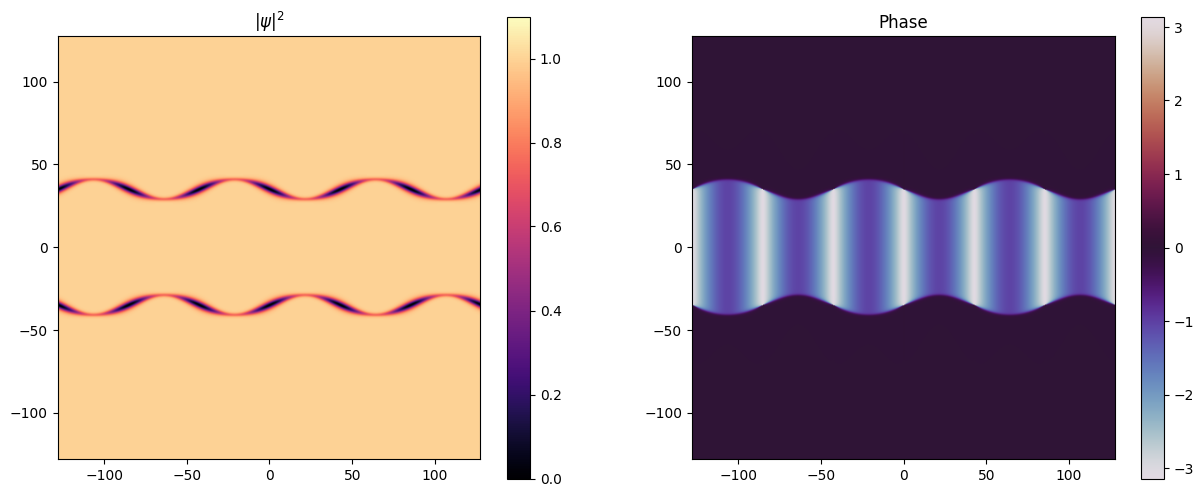

In [23]:
fig, (ax_dens, ax_phase) = plt.subplots(1, 2, figsize=(15, 6))

im_dens = ax_dens.imshow(cp.abs(wfn.component).get()**2, extent=[X.min(), X.max(), Y.min(), Y.max()],
                         cmap='magma', origin='lower', vmin=0, vmax=1.1)
ax_dens.set_title(fr"$|\psi|^2$")
plt.colorbar(im_dens, ax=ax_dens)

im_phase = ax_phase.imshow(cp.angle(wfn.component).get(), extent=[X.min(), X.max(), Y.min(), Y.max()],
                          cmap='twilight', origin='lower', vmin=-np.pi, vmax=np.pi)
ax_phase.set_title(fr"Phase")
plt.colorbar(im_phase, ax=ax_phase)

In [24]:
steps_per_frame = 500
n_frames = 100  
save_every = 5
time_history = []
energy_history = []
atom_history = []

def update(frame):
    if frame > 0:
        t_start_frame = (frame - 1) * steps_per_frame * dt
        for s in range(steps_per_frame):
            step_wavefunction(wfn, params)

            if s % save_every == 0:
                psi = wfn.component

                current_t_global = t_start_frame + (s * dt)
                dens = cp.abs(psi)**2
           
                N = cp.sum(dens) * dA
                psi_k = cp.fft.fftn(psi)
                E_kin = 0.5 * cp.sum(K2 * cp.abs(psi_k)**2) * dA / (pts[0] * pts[1])
                E_int = 0.5 * g * cp.sum(dens**2) * dA
      
                time_history.append(current_t_global)
                atom_history.append(float(N.get()))
                energy_history.append(float((E_kin + E_int).get()))
        
        
    psi_cpu = wfn.component.get()
    dens_cpu = np.abs(psi_cpu)**2
    phase_cpu = np.angle(psi_cpu)
        
    im_dens.set_data(dens_cpu)
    im_phase.set_data(phase_cpu)
        
    current_time = frame * steps_per_frame * dt
    fig.suptitle(f"t = {current_time:.2f}", fontsize=16)
    return [im_dens, im_phase]

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)

ani.save("dark_solitons_2d/ds2d.html", writer='html')

plt.close(fig)

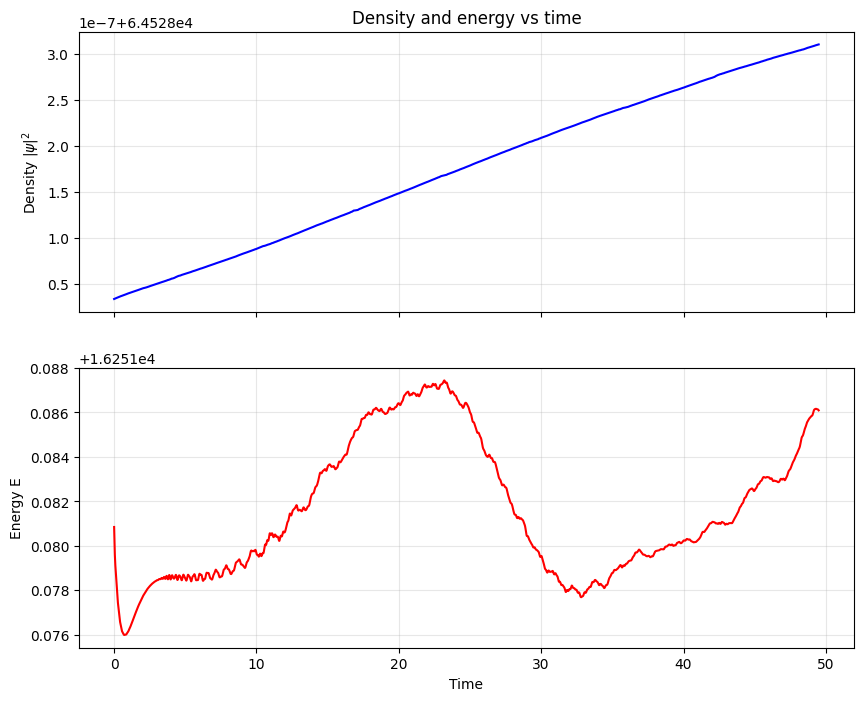

In [25]:
fig_final, (ax_at, ax_en) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_at.plot(time_history, atom_history, color='blue', lw=1.5)
ax_at.set_title("Density and energy vs time")
ax_at.set_ylabel(r"Density $|\psi|^2$")
ax_at.grid(True, alpha=0.3)

ax_en.plot(time_history, energy_history, color='red', lw=1.5)
ax_en.set_xlabel("Time")
ax_en.set_ylabel("Energy E")
ax_en.grid(True, alpha=0.3)
plt.savefig("dark_solitons_2d/te_ds2d.pdf")
plt.show()